# 3D Isomap Visualization


Loading: k:\03_manifold_changecolor_re\git_check_final\git_folder\pool_zone_CA2pos_map.mat
Inferred spatial map size from .mat file: 18 x 19
Fitting 3D Isomap...


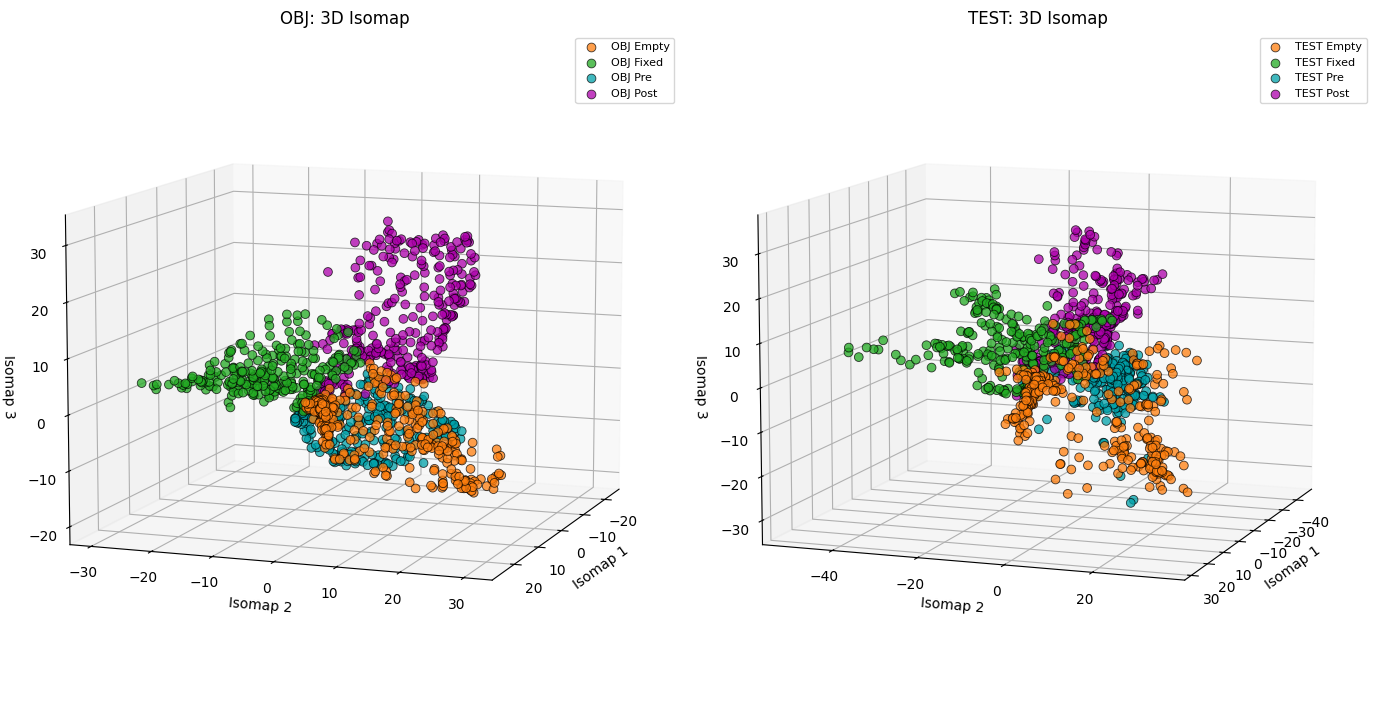

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ======================
# Settings
# ======================
CELL_TYPE = "ca2pos"          # "ca2pos" or "ca2other"
REFERENCE_SESSION = "OBJ"     # "OBJ" or "TEST"

K_NEIGHBORS = 50

ELEVATION = 10
AZIMUTH = 20

zone_labels = ["Empty", "Fixed", "Pre", "Post"]
zone_keys = ["empty", "familiar", "pre_move", "post_move"]

colors = ["#ff7f0e", "#23aa23", "#00A1A9", "#ad00ab"]

BASE_DIR = Path.cwd()
mat_path = BASE_DIR / "git_folder" / "pool_zone_CA2pos_map.mat"

output_dir = BASE_DIR / "output"
output_dir.mkdir(exist_ok=True)

out_3d = output_dir / f"spatial_bin_embeddings_3D_{CELL_TYPE}.jpg"


# ======================
# Helper functions
# ======================
def get_var(data, name):
    if name not in data:
        available = [k for k in data.keys() if not k.startswith("__")]
        raise KeyError(f"Missing variable: {name}\nAvailable keys: {available}")
    return data[name]


def first_valid_2d_map(maps):
    if isinstance(maps, np.ndarray):
        if maps.dtype == object:
            maps = maps.flatten()
        elif maps.ndim == 2:
            return maps
        elif maps.ndim > 2:
            maps = [maps[i] for i in range(maps.shape[0])]

    for m in maps:
        arr = np.asarray(m)
        if arr.ndim == 2 and arr.size > 0:
            return arr

    raise ValueError("Could not find a valid 2D spatial map to infer bin size.")


def infer_spatial_shape(data, cell_type):

    candidate_names = [
        f"pool_split_maps_OBJ_empty_{cell_type}",
        f"pool_split_maps_OBJ_familiar_{cell_type}",
        f"pool_split_maps_OBJ_pre_move_{cell_type}",
        f"pool_split_maps_OBJ_post_move_{cell_type}",
        f"pool_split_maps_TEST_empty_{cell_type}",
        f"pool_split_maps_TEST_familiar_{cell_type}",
        f"pool_split_maps_TEST_pre_move_{cell_type}",
        f"pool_split_maps_TEST_post_move_{cell_type}",
    ]

    for name in candidate_names:
        if name in data:
            valid_map = first_valid_2d_map(data[name])
            return valid_map.shape

    raise KeyError(f"No map variables found for CELL_TYPE={cell_type}")


def pad_maps(maps, target_shape):
    if isinstance(maps, np.ndarray):
        if maps.dtype == object:
            maps = maps.flatten()
        elif maps.ndim > 2:
            maps = [maps[i] for i in range(maps.shape[0])]

    padded = []

    for m in maps:
        arr = np.asarray(m)
        out = np.zeros(target_shape)

        if arr.size == 0:
            padded.append(out)
            continue

        if arr.ndim == 2:
            r = min(arr.shape[0], target_shape[0])
            c = min(arr.shape[1], target_shape[1])
            out[:r, :c] = arr[:r, :c]
        else:
            flat = arr.flatten()
            n = min(flat.size, np.prod(target_shape))
            out.flat[:n] = flat[:n]

        padded.append(out)

    return padded


def maps_to_matrix(maps, spatial_shape):
    padded = pad_maps(maps, spatial_shape)
    n_bins = spatial_shape[0] * spatial_shape[1]

    X = np.zeros((n_bins, len(padded)))

    for i, m in enumerate(padded):
        X[:, i] = m.flatten()

    return X


def load_session(data, session, cell_type):
    return [
        get_var(data, f"pool_split_maps_{session}_empty_{cell_type}"),
        get_var(data, f"pool_split_maps_{session}_familiar_{cell_type}"),
        get_var(data, f"pool_split_maps_{session}_pre_move_{cell_type}"),
        get_var(data, f"pool_split_maps_{session}_post_move_{cell_type}"),
    ]


def stack_session(zone_maps, spatial_shape):
    return np.vstack([maps_to_matrix(m, spatial_shape) for m in zone_maps])


# ======================
# Load data
# ======================
print(f"Loading: {mat_path}")
data = loadmat(mat_path, simplify_cells=True)

spatial_shape = infer_spatial_shape(data, CELL_TYPE)
n_rows, n_cols = spatial_shape
n_bins_per_zone = n_rows * n_cols

print(f"Inferred spatial map size from .mat file: {n_rows} x {n_cols}")

obj_maps = load_session(data, "OBJ", CELL_TYPE)
test_maps = load_session(data, "TEST", CELL_TYPE)

X_obj = stack_session(obj_maps, spatial_shape)
X_test = stack_session(test_maps, spatial_shape)

if REFERENCE_SESSION == "OBJ":
    X_ref, X_proj = X_obj, X_test
    ref_label, proj_label = "OBJ", "TEST"
else:
    X_ref, X_proj = X_test, X_obj
    ref_label, proj_label = "TEST", "OBJ"

zone_assignment = np.repeat(np.arange(4), n_bins_per_zone)

X_ref = np.nan_to_num(X_ref, nan=0.0, posinf=0.0, neginf=0.0)
X_proj = np.nan_to_num(X_proj, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_ref_scaled = scaler.fit_transform(X_ref)
X_proj_scaled = scaler.transform(X_proj)


print("Fitting 3D Isomap...")
iso_3d = Isomap(n_neighbors=K_NEIGHBORS, n_components=3)

Y_ref_3d = iso_3d.fit_transform(X_ref_scaled)
Y_proj_3d = iso_3d.transform(X_proj_scaled)

fig = plt.figure(figsize=(14, 7))

ax = fig.add_subplot(121, projection="3d")
for z in range(4):
    mask = zone_assignment == z
    ax.scatter(
        Y_ref_3d[mask, 0],
        Y_ref_3d[mask, 1],
        Y_ref_3d[mask, 2],
        c=[colors[z]],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.6,
        label=f"{ref_label} {zone_labels[z]}",
    )

ax.set_title(f"{ref_label}: 3D Isomap")
ax.set_xlabel("Isomap 1")
ax.set_ylabel("Isomap 2")
ax.set_zlabel("Isomap 3")
ax.view_init(elev=ELEVATION, azim=AZIMUTH)
ax.legend(fontsize=8)


ax = fig.add_subplot(122, projection="3d")
for z in range(4):
    mask = zone_assignment == z
    ax.scatter(
        Y_proj_3d[mask, 0],
        Y_proj_3d[mask, 1],
        Y_proj_3d[mask, 2],
        c=[colors[z]],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.6,
        label=f"{proj_label} {zone_labels[z]}",
    )

ax.set_title(f"{proj_label}: 3D Isomap")
ax.set_xlabel("Isomap 1")
ax.set_ylabel("Isomap 2")
ax.set_zlabel("Isomap 3")
ax.view_init(elev=ELEVATION, azim=AZIMUTH)
ax.legend(fontsize=8)


plt.tight_layout()
plt.savefig(out_3d, dpi=300, bbox_inches="tight", format="jpg")
plt.show()

